[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T02_D_occbin_zlb_regimes.ipynb)

# Topic 2.D: Occasionally Binding Constraints, The Zero Lower Bound & Liquidity Traps (OccBin)

### Advanced Macroeconomics (MAV) — Master in Economics, ITAM
**Author**: Jorge Alonso Ortiz

> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.

In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 1. Theoretical Motivation: Why Linear Perturbation Fails at Physical Boundaries

In modern quantitative macroeconomics, dynamic stochastic general equilibrium (DSGE) models are traditionally solved using first-order Taylor expansions around the deterministic steady state (Klein 2000, Schmitt-Grohé & Uribe 2004). Linear perturbation assumes that policy functions are differentiable planes everywhere in state space.

However, actual market economies are constrained by **fundamental non-linearities and physical boundaries**:
1. **The Zero Lower Bound (ZLB) / Effective Lower Bound (ELB)**: The nominal interest rate on central bank reserves cannot plunge significantly below zero because households and financial institutions can arbitrage cash holding:
   $$i_t \ge 0 \quad \iff \quad \hat{r}_t \ge -r_{ss}$$
2. **Collateral & Borrowing Constraints (Sudden Stops)**: Emerging economy external borrowing cannot exceed a fraction of physical collateral: $d_{t+1} \le \kappa q_t k_t$ (Mendoza 2010).
3. **Downward Nominal Wage Rigidity (DNWR)**: Workers resist cuts to nominal hourly wages: $\Delta W_t \ge 0$ (Schmitt-Grohé & Uribe 2016).

When an economy suffers a massive contractionary demand shock (such as during the 2008 Great Financial Crisis or the 2020 COVID-19 shock), linear perturbation predicts that the central bank cuts the nominal policy rate to deeply negative levels (in Section 1 of this notebook, $-8.8\%$ annualized). Because nominal rates cannot fall below zero in reality, the real interest rate:
$$r_{t}^{\text{real}} = i_t - \mathbb{E}_t \pi_{t+1}$$
is driven **up** by expected deflation, sparking a severe **deflationary spiral** and amplifying the output collapse.

### The Piecewise-Linear Solution: Guerrieri & Iacoviello (2015, JME)
To solve models with occasionally binding constraints without the prohibitive curse of dimensionality of global Value Function Iteration (VFI), Guerrieri & Iacoviello (2015) introduced the **OccBin** algorithm:
- **Reference Regime ($M_1$)**: The unconstrained economy governed by an active Taylor rule.
- **Constrained Regime ($M_2$)**: The economy when the constraint binds (nominal rate clamped at the zero floor).
- **Endogenous Duration ($T^*$)**: OccBin solves the exact piecewise-linear Kuhn-Tucker conditions under perfect foresight via backward recursion, determining endogenously how many quarters the economy stays trapped at the lower bound before smoothly lifting off back to the reference regime.

### The 3-Equation New Keynesian Framework
In this notebook, we examine a canonical New Keynesian DSGE model:
1. **Dynamic Investment-Savings (IS) Curve**:
   $$y_t = \mathbb{E}_t y_{t+1} - \frac{1}{\sigma}\left(r_t - \mathbb{E}_t \pi_{t+1}\right) + g_t$$
2. **New Keynesian Phillips Curve (Calvo Price Stickiness)**:
   $$\pi_t = \beta \mathbb{E}_t \pi_{t+1} + \kappa y_t$$
3. **Monetary Policy Rule with Occasionally Binding Floor**:
   $$r_t = \max\left(-r_{ss}, \; \phi_\pi \pi_t + \phi_y y_t + \varepsilon_{r,t}\right)$$
4. **Exogenous Aggregate Demand / Preference Shock**:
   $$g_t = \rho_g g_{t-1} + \varepsilon_{g,t}$$

In [2]:
# ==============================================================================
# Declarative Model Ingestion & OccBin Constraint Setup
# ==============================================================================
from puremacro.dsge import load_mod, OccBinConstraint, solve_occbin, build_dynare, make_state_space_from_varobs
from puremacro.dsge.occbin import solve_multiconstraint_occbin, piecewise_kalman_filter
from puremacro.state_space import kalman_filter

# Resolve model paths across local repository and Colab environments
from _datos import ruta_modelo

# Resolve model paths across local repository, sandbox, and Colab environments
ref_mod_path = ruta_modelo("nk_zlb_ref.mod")
cons_mod_path = ruta_modelo("nk_zlb_cons.mod")

# Load canonical Dynare specifications natively via puremacro
ref_model = load_mod(ref_mod_path)
# The constrained regime pegs r = -r_ss, dropping the Taylor rule, so on its own it
# fails Blanchard-Kahn by construction: with the policy rate fixed there is nothing
# left to anchor inflation. That is expected in Guerrieri-Iacoviello -- the ZLB regime
# is only well defined as a segment of the piecewise path, whose terminal condition
# comes from the reference regime. strict=False returns its structural matrices
# instead of raising; solve_occbin needs exactly those.
cons_model = load_mod(cons_mod_path, strict=False)

print(f"Reference Model loaded: {ref_mod_path}")
print(f"  States  : {ref_model.states}")
print(f"  Controls: {ref_model.controls}")
print(f"  Shocks  : {ref_model.shocks}")

# Define the occasionally binding constraint:
# When notional nominal rate r falls below -r_ss (-1.0% quarterly = 0% level), the floor binds
r_ss = float(getattr(ref_model, "_params", {}).get("r_ss", 0.01))
constraint = OccBinConstraint(variable="r", threshold=-r_ss, operator="<")

print(f"\nOccBin Constraint declared: {constraint}")
print(f"Steady-State Quarterly Policy Rate: {r_ss:.4f} ({r_ss * 400:.2f}% annualized)")
print(f"ZLB Floor on Deviation: r >= {-r_ss:.4f}")

Reference Model loaded: modelos/nk_zlb_ref.mod
  States  : ('g',)
  Controls: ('y', 'pi', 'r')
  Shocks  : ('eps_r', 'eps_g')

OccBin Constraint declared: OccBinConstraint(r < -0.01)
Steady-State Quarterly Policy Rate: 0.0100 (4.00% annualized)
ZLB Floor on Deviation: r >= -0.0100


## 2. Section 1: The Asymmetry Arena — Breaking Linear Symmetry at the ZLB

In a linear world, macroeconomic shocks exhibit perfect mirror symmetry:
$$\text{IRF}(+\varepsilon) = -\text{IRF}(-\varepsilon)$$
An aggregate demand expansion of $+2.5\%$ and an aggregate demand contraction of $-2.5\%$ must generate output responses of identical magnitude and opposite sign.

**In the real world, this symmetry fails completely because of the Zero Lower Bound**:
- When a positive demand shock hits ($\varepsilon_g = +2.5\%$), the central bank increases nominal interest rates along the Taylor rule ($i_t \uparrow$), leaning against inflation and smoothly moderating the boom.
- When a negative demand shock hits ($\varepsilon_g = -2.5\%$), the central bank cuts rates until it hits the zero floor. Beyond that point, monetary policy is paralyzed. Expected deflation increases the real interest rate, depressing consumption and creating an asymmetric output crash.

In addition, `solve_occbin` traces the exact binary regime transition sequence $R_t \in \{0, 1\}$ (`res_neg.regimes`), recording the endogenous spell where the economy binds at the ZLB ($R_t=1$) before returning smoothly to the unconstrained reference regime ($R_t=0$), strictly respecting the zero lower bound ($r_t \ge -r_{ss}$).

Below, we solve both the linear counterfactual and the OccBin piecewise-linear solution under both shocks.

MACROECONOMIC SHOCK ASYMMETRY SCORECARD (T=1 IMPACT)
Positive Demand (+2.5%) : Output Gap =  +3.78%, Policy Rate =  16.79% ann (ZLB periods: 0)
Linear Negative (-2.5%) : Output Gap =  -3.78%, Policy Rate =  -8.79% ann (Unconstrained shadow)
OccBin Negative (-2.5%) : Output Gap = -10.91%, Policy Rate =   0.00% ann (ZLB periods: 6)
----------------------------------------------------------------------------
Asymmetry Ratio (|y_neg| / y_pos) : 2.89x (Linear model is identically 1.00x)
ZLB Output Gap Loss vs Linear   : 7.13 percentage points deeper recession

OCCBIN BINARY REGIME TRANSITION DYNAMICS
Regime History Sequence (0=Reference, 1=Binding ZLB):
  [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Total Quarters at ZLB: 6 quarters
Terminal Regime: 0 (smooth liftoff to reference regime)
Minimum Policy Rate Deviation: -0.010000 (ZLB floor: -0.010000)


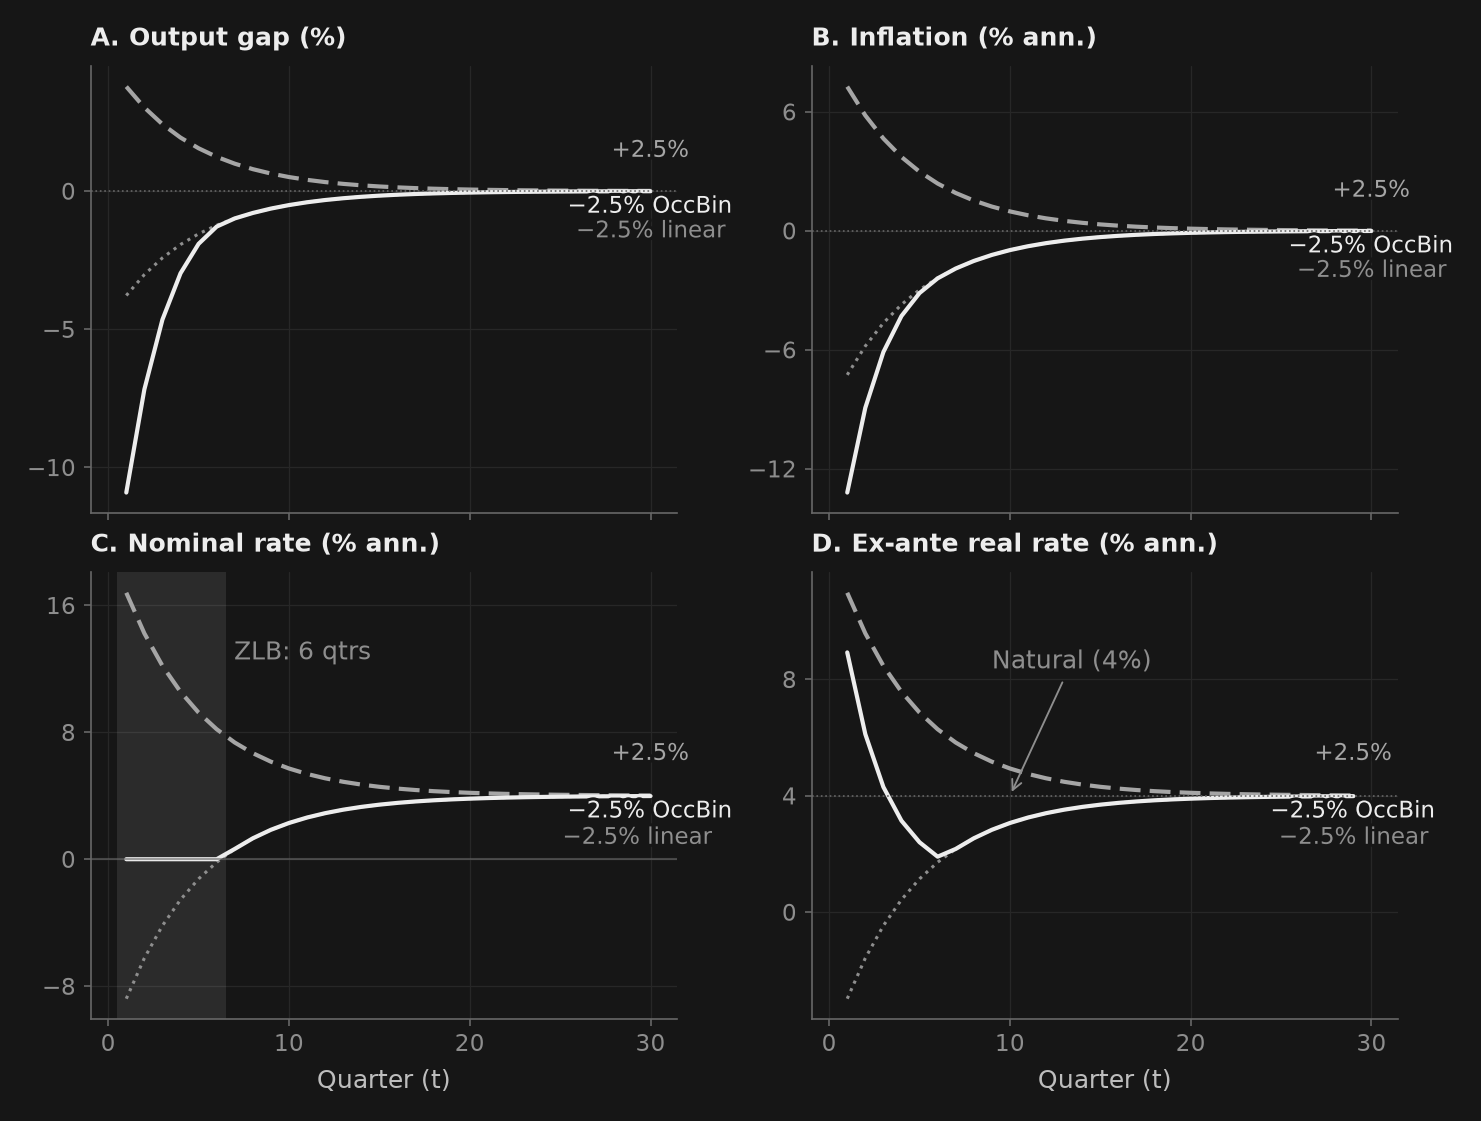

In [3]:
# ==============================================================================
# Simulation 1: The Shock Asymmetry Laboratory (+2.5% vs -2.5%)
# ==============================================================================
horizon = 30
shock_size = 0.025  # 2.5% demand shock

# 1. OccBin Piecewise-Linear Solutions
shock_pos = np.array([0.0, shock_size])
shock_neg = np.array([0.0, -shock_size])

res_pos = solve_occbin(ref_model, cons_model, constraint, shock_sequence=shock_pos, horizon=horizon)
res_neg = solve_occbin(ref_model, cons_model, constraint, shock_sequence=shock_neg, horizon=horizon)

# 2. Pure Linear Counterfactual (Taylor rule allowed to cut into negative rates)
dr = ref_model.decision_rules()
P_0 = np.zeros((len(ref_model.variables), len(ref_model.variables)))
for s in ref_model.states:
    idx_s = list(ref_model.variables).index(s)
    P_0[:, idx_s] = dr.ghx[s].values

lin_neg = np.zeros((horizon, len(ref_model.variables)))
lin_neg[0] = dr.ghu.values @ shock_neg
for t in range(1, horizon):
    lin_neg[t] = P_0 @ lin_neg[t - 1]

lin_df = pd.DataFrame(lin_neg, columns=ref_model.variables)

# Quantitative Scorecard
y_pos_0 = res_pos["y"].iloc[0] * 100
r_pos_0 = (r_ss + res_pos["r"].iloc[0]) * 400
y_neg_0 = res_neg["y"].iloc[0] * 100
r_neg_0 = (r_ss + res_neg["r"].iloc[0]) * 400
y_lin_0 = lin_df["y"].iloc[0] * 100
r_lin_0 = (r_ss + lin_df["r"].iloc[0]) * 400

asymmetry_ratio = abs(y_neg_0) / y_pos_0
zlb_penalty = abs(y_neg_0) - abs(y_lin_0)

print("=" * 76)
print("MACROECONOMIC SHOCK ASYMMETRY SCORECARD (T=1 IMPACT)")
print("=" * 76)
print(f"Positive Demand (+2.5%) : Output Gap = {y_pos_0:+6.2f}%, Policy Rate = {r_pos_0:6.2f}% ann (ZLB periods: {res_pos.binding_periods})")
print(f"Linear Negative (-2.5%) : Output Gap = {y_lin_0:+6.2f}%, Policy Rate = {r_lin_0:6.2f}% ann (Unconstrained shadow)")
print(f"OccBin Negative (-2.5%) : Output Gap = {y_neg_0:+6.2f}%, Policy Rate = {r_neg_0:6.2f}% ann (ZLB periods: {res_neg.binding_periods})")
print("-" * 76)
print(f"Asymmetry Ratio (|y_neg| / y_pos) : {asymmetry_ratio:.2f}x (Linear model is identically 1.00x)")
print(f"ZLB Output Gap Loss vs Linear   : {zlb_penalty:.2f} percentage points deeper recession")
print("=" * 76)

# Binary Regime Sequence and ZLB Floor Verification
print("\n" + "=" * 76)
print("OCCBIN BINARY REGIME TRANSITION DYNAMICS")
print("=" * 76)
print(f"Regime History Sequence (0=Reference, 1=Binding ZLB):")
print(f"  {res_neg.regimes}")
print(f"Total Quarters at ZLB: {res_neg.binding_periods} quarters")
print(f"Terminal Regime: {res_neg.regimes[-1]} (smooth liftoff to reference regime)")
print(f"Minimum Policy Rate Deviation: {res_neg['r'].min():.6f} (ZLB floor: {-r_ss:.6f})")
print("=" * 76)

assert res_neg.converged is True, "OccBin regime iterations must converge."
assert res_neg.regimes[-1] == 0, "Terminal regime must return to unconstrained reference regime."
assert np.all(res_neg["r"].values >= -r_ss - 1e-10), "ZLB floor violation: r_t fell below -r_ss!"

# Visualization
from matplotlib.ticker import MaxNLocator

time = np.arange(1, horizon + 1)

# The slide harness sets rcParams["figure.figsize"] to the slot BEFORE the cell draws.
# Inheriting it is what makes one cell serve both readings: a figure laid out at
# notebook size and shrunk afterwards keeps its annotations where the old axes were.
# In the notebook the house 2x2 still applies.
_ranura = tuple(plt.rcParams["figure.figsize"]) if os.environ.get("MAV_NB_PERFIL") == "lamina" else None
fig, axes = _nbstyle.figura(2, 2, sharex=True, figsize=_ranura)

# At slot width a column is ~2.6 in: seven ticks per axis pile on top of each other.
for _ax in axes.flat:
    _ax.xaxis.set_major_locator(MaxNLocator(4, integer=True))
    _ax.yaxis.set_major_locator(MaxNLocator(4))

# The linear counterfactual stays thinner than the two OccBin paths in both profiles.
lw_lin = plt.rcParams["lines.linewidth"] * 0.75

# The units ride in each panel's title: at a 2.6-in column a rotated axis label is
# taller than the panel itself and gets clipped.
ETIQ = ("+2.5%", "−2.5% linear", "−2.5% OccBin")

# Panel A: Output Gap
ax = axes[0, 0]
ax.plot(time, res_pos["y"] * 100, label=ETIQ[0], **_nbstyle.S2)
ax.plot(time, lin_df["y"] * 100, label=ETIQ[1], color=_nbstyle.NOTA, linestyle=":", linewidth=lw_lin)
ax.plot(time, res_neg["y"] * 100, label=ETIQ[2], **_nbstyle.S1)
ax.axhline(0, color=_nbstyle.SPINE, linestyle=":", linewidth=0.8)
ax.set_title("A. Output gap (%)")
_nbstyle.etiquetar(ax)

# Panel B: Inflation (Annualized)
ax = axes[0, 1]
ax.plot(time, res_pos["pi"] * 400, label=ETIQ[0], **_nbstyle.S2)
ax.plot(time, lin_df["pi"] * 400, label=ETIQ[1], color=_nbstyle.NOTA, linestyle=":", linewidth=lw_lin)
ax.plot(time, res_neg["pi"] * 400, label=ETIQ[2], **_nbstyle.S1)
ax.axhline(0, color=_nbstyle.SPINE, linestyle=":", linewidth=0.8)
ax.set_title("B. Inflation (% ann.)")
_nbstyle.etiquetar(ax)

# Panel C: Nominal Policy Rate (Annualized Level)
ax = axes[1, 0]
ax.plot(time, (r_ss + res_pos["r"]) * 400, label=ETIQ[0], **_nbstyle.S2)
ax.plot(time, (r_ss + lin_df["r"]) * 400, label=ETIQ[1], color=_nbstyle.NOTA, linestyle=":", linewidth=lw_lin)
ax.plot(time, (r_ss + res_neg["r"]) * 400, label=ETIQ[2], **_nbstyle.S1)
ax.axhline(0, color=_nbstyle.SPINE, linestyle="-", linewidth=1.0, alpha=0.6)
ax.axvspan(0.5, res_neg.binding_periods + 0.5, color=_nbstyle.RECESION, lw=0)
ax.annotate(f"ZLB: {res_neg.binding_periods} qtrs", xy=(res_neg.binding_periods + 0.5, 13.0),
            xytext=(4, 0), textcoords="offset points", ha="left", va="center", color=_nbstyle.NOTA)
ax.set_xlabel("Quarter (t)")
ax.set_title("C. Nominal rate (% ann.)")
_nbstyle.etiquetar(ax)

# Panel D: Real Interest Rate Level
ax = axes[1, 1]
r_real_pos = (res_pos["r"].iloc[:-1].values - res_pos["pi"].iloc[1:].values + r_ss) * 400
r_real_lin = (lin_df["r"].iloc[:-1].values - lin_df["pi"].iloc[1:].values + r_ss) * 400
r_real_neg = (res_neg["r"].iloc[:-1].values - res_neg["pi"].iloc[1:].values + r_ss) * 400

ax.plot(time[:-1], r_real_pos, label=ETIQ[0], **_nbstyle.S2)
ax.plot(time[:-1], r_real_lin, label=ETIQ[1], color=_nbstyle.NOTA, linestyle=":", linewidth=lw_lin)
ax.plot(time[:-1], r_real_neg, label=ETIQ[2], **_nbstyle.S1)
ax.axhline(r_ss * 400, color=_nbstyle.SPINE, linestyle=":", linewidth=0.8)
# The natural-rate line is named from the empty space above: next to its own trace the three paths cover it
ax.annotate(f"Natural ({r_ss * 400:.0f}%)", xy=(10.0, r_ss * 400), xytext=(9.0, 8.6),
            ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.set_xlabel("Quarter (t)")
ax.set_title("D. Ex-ante real rate (% ann.)")
_nbstyle.etiquetar(ax)

plt.show()


## 3. Section 2: The Keynesian Multiplier Supercharge at the Zero Lower Bound

A foundational result in macroeconomic policy analysis (Christiano, Eichenbaum & Rebelo 2011, *JPE*; Eggertsson 2011; Woodford 2011) concerns the **state-dependence of the government spending multiplier**:

$$\text{Multiplier} = \frac{\partial Y_t}{\partial G_t}$$

### The Transmission Channel: Crowding Out vs. Crowding In
1. **Normal Times (Active Taylor Rule)**:
   - When the government increases spending $G_t \uparrow$, aggregate demand and inflation rise.
   - Because the Taylor rule satisfies the Taylor Principle ($\phi_\pi = 1.5 > 1$), the central bank responds aggressively by hiking the nominal policy rate $i_t$ by more than the rise in inflation.
   - The **real interest rate rises** ($r_t^{\text{real}} \uparrow$), which induces households to postpone consumption and firms to reduce investment. Private spending is **crowded out**, keeping the output multiplier modest (in the literature, $\sim 0.7 - 0.9$; in this model, $1.5$).

2. **Liquidity Trap (Zero Lower Bound Floor)**:
   - At the ZLB, the nominal policy rate is pinned at zero ($i_t = 0$).
   - When fiscal stimulus $G_t \uparrow$ stimulates activity, it raises future expected inflation ($\mathbb{E}_t \pi_{t+1} \uparrow$).
   - Because the nominal rate cannot move, the **real interest rate drops directly**:
     $$\Delta r_{t}^{\text{real}} = 0 - \Delta \mathbb{E}_t \pi_{t+1} < 0$$
   - A lower real interest rate during a recession stimulates consumption and investment (**crowding in**), causing the fiscal multiplier to **supercharge well above 2.0** (in this model, $6.8$)!

FISCAL SPENDING MULTIPLIER COMPARISON
Normal Times Fiscal Multiplier (Taylor rule active) :  1.512
ZLB Liquidity Trap Multiplier (Nominal rate pegged)  :  6.838
Fiscal Multiplier Amplification Ratio                 :   4.52x


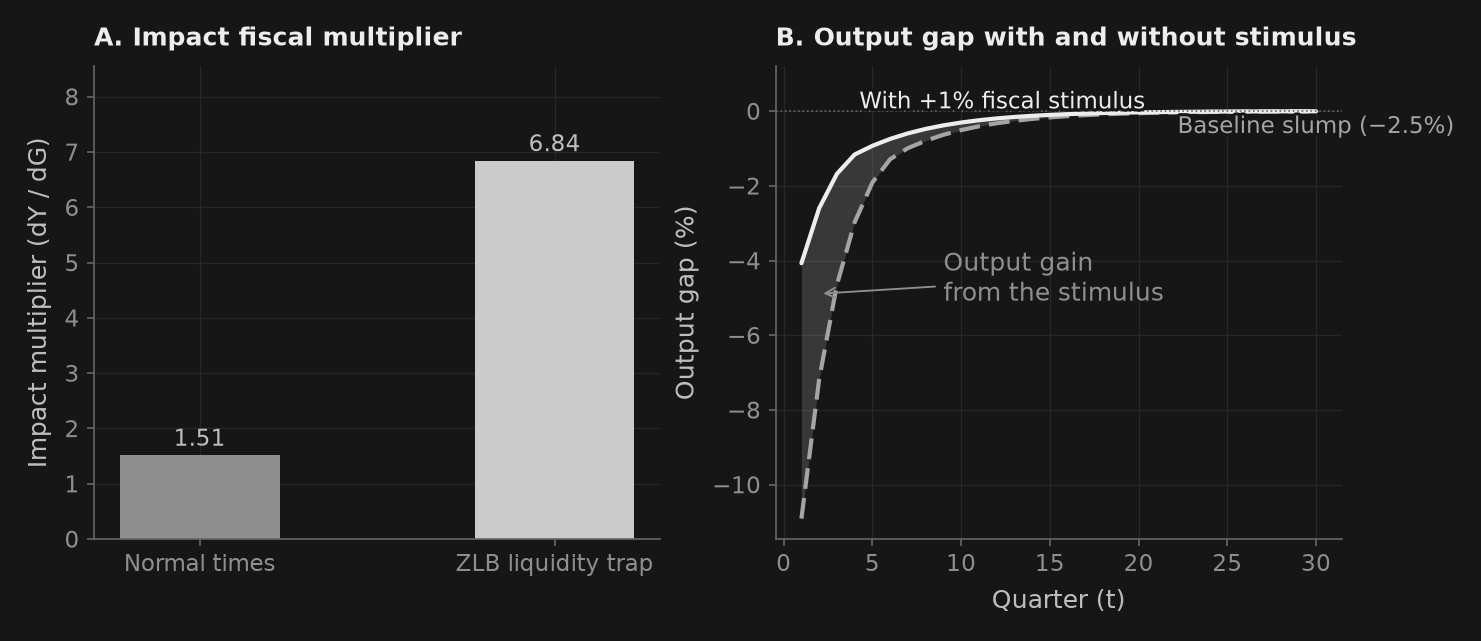

In [4]:
# ==============================================================================
# Simulation 2: Fiscal Multiplier Comparison (Normal Times vs ZLB)
# ==============================================================================
stimulus_size = 0.01  # +1% of GDP fiscal expansion

# 1. Normal Times Multiplier (Zero Baseline vs +1% Stimulus)
res_normal_base = solve_occbin(ref_model, cons_model, constraint, shock_sequence=np.array([0.0, 0.0]), horizon=horizon)
res_normal_stim = solve_occbin(ref_model, cons_model, constraint, shock_sequence=np.array([0.0, stimulus_size]), horizon=horizon)
multiplier_normal = (res_normal_stim["y"].iloc[0] - res_normal_base["y"].iloc[0]) / stimulus_size

# 2. ZLB Liquidity Trap Multiplier (-2.5% Recession vs -1.5% Net with Stimulus)
res_zlb_base = res_neg  # -2.5% demand shock
shock_zlb_stim = np.array([0.0, -shock_size + stimulus_size])  # -1.5% net shock
res_zlb_stim = solve_occbin(ref_model, cons_model, constraint, shock_sequence=shock_zlb_stim, horizon=horizon)
multiplier_zlb = (res_zlb_stim["y"].iloc[0] - res_zlb_base["y"].iloc[0]) / stimulus_size

amplification = multiplier_zlb / multiplier_normal

print("=" * 76)
print("FISCAL SPENDING MULTIPLIER COMPARISON")
print("=" * 76)
print(f"Normal Times Fiscal Multiplier (Taylor rule active) : {multiplier_normal:6.3f}")
print(f"ZLB Liquidity Trap Multiplier (Nominal rate pegged)  : {multiplier_zlb:6.3f}")
print(f"Fiscal Multiplier Amplification Ratio                 : {amplification:6.2f}x")
print("=" * 76)

# Visualization
fig, (ax1, ax2) = _nbstyle.figura(1, 2)

# Bar chart of impact multiplier
ax1.bar(["Normal times", "ZLB liquidity trap"], [multiplier_normal, multiplier_zlb], color=[_nbstyle.BARRA_COLORES[1], _nbstyle.BARRA_COLORES[0]], width=0.45)
ax1.set_ylabel("Impact multiplier (dY / dG)")
ax1.set_title("A. Impact fiscal multiplier")
ax1.set_ylim(0, max(multiplier_normal, multiplier_zlb) * 1.25)
_nbstyle.etiquetar_barras(ax1, fmt="{:.2f}")

# Dynamic trajectories under stimulus vs baseline in liquidity trap
ax2.plot(time, res_zlb_base["y"] * 100, label="Baseline slump (−2.5%)", **_nbstyle.S2)
ax2.plot(time, res_zlb_stim["y"] * 100, label="With +1% fiscal stimulus", **_nbstyle.S1)
ax2.fill_between(time, res_zlb_base["y"] * 100, res_zlb_stim["y"] * 100, color=_nbstyle.BANDA, lw=0)
ax2.axhline(0, color=_nbstyle.SPINE, linestyle=":", linewidth=0.8)
ax2.set_ylim(top=1.2)
ax2.annotate("Output gain\nfrom the stimulus", xy=(time[1], (res_zlb_base["y"].iloc[1] + res_zlb_stim["y"].iloc[1]) * 50),
             xytext=(9.0, -4.5), ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax2.set_xlabel("Quarter (t)")
ax2.set_ylabel("Output gap (%)")
ax2.set_title("B. Output gap with and without stimulus")
_nbstyle.etiquetar(ax2)

plt.show()


## 4. Section 3: Endogenous ZLB Duration $T^*$ & The Deflationary Spiral Monotonicity

Unlike simple ad-hoc pegging models, the Guerrieri & Iacoviello (2015) algorithm does not assume how long the economy remains trapped at zero. The duration $T^*$ is an **endogenous rational expectations equilibrium outcome**:

$$T^* = \min \left\{ t \ge 1 \;\Big|\; i_t^{\text{shadow}} \ge -r_{ss} \right\}$$

### The Deflationary Spiral Acceleration
As the adverse demand shock becomes incrementally larger:
1. The duration $T^*$ steps up discretely (from 0 to 2, 3, 5, 6 and 7 quarters).
2. Each additional quarter spent at the ZLB compounds expected deflation in the New Keynesian Phillips Curve:
   $$\pi_t = \sum_{j=0}^{T^*} \beta^j \kappa y_{t+j} + \beta^{T^*+1} \mathbb{E}_t \pi_{t+T^*+1}$$
3. Because higher expected future deflation raises current real interest rates, the initial output collapse accelerates **non-linearly** beyond a critical shock threshold.

OCCBIN DURATION & DEFLATIONARY SPIRAL MONOTONICITY SWEEP
 Shock (%)  ZLB Duration T* (qtrs)  Output Trough (%)  Inflation Trough (% ann.)  Converged  Iterations
   -0.5               0                 -0.755814              -1.453488            True         1     
   -1.0               2                 -1.816279              -3.038047            True         2     
   -1.5               3                 -4.072749              -5.483027            True         2     
   -2.0               5                 -7.179398              -8.927097            True         2     
   -2.5               6                -10.911173             -13.202295            True         2     
   -3.0               7                -15.127353             -18.148273            True         2     
   -3.5               7                -19.964928             -23.975065            True         2     


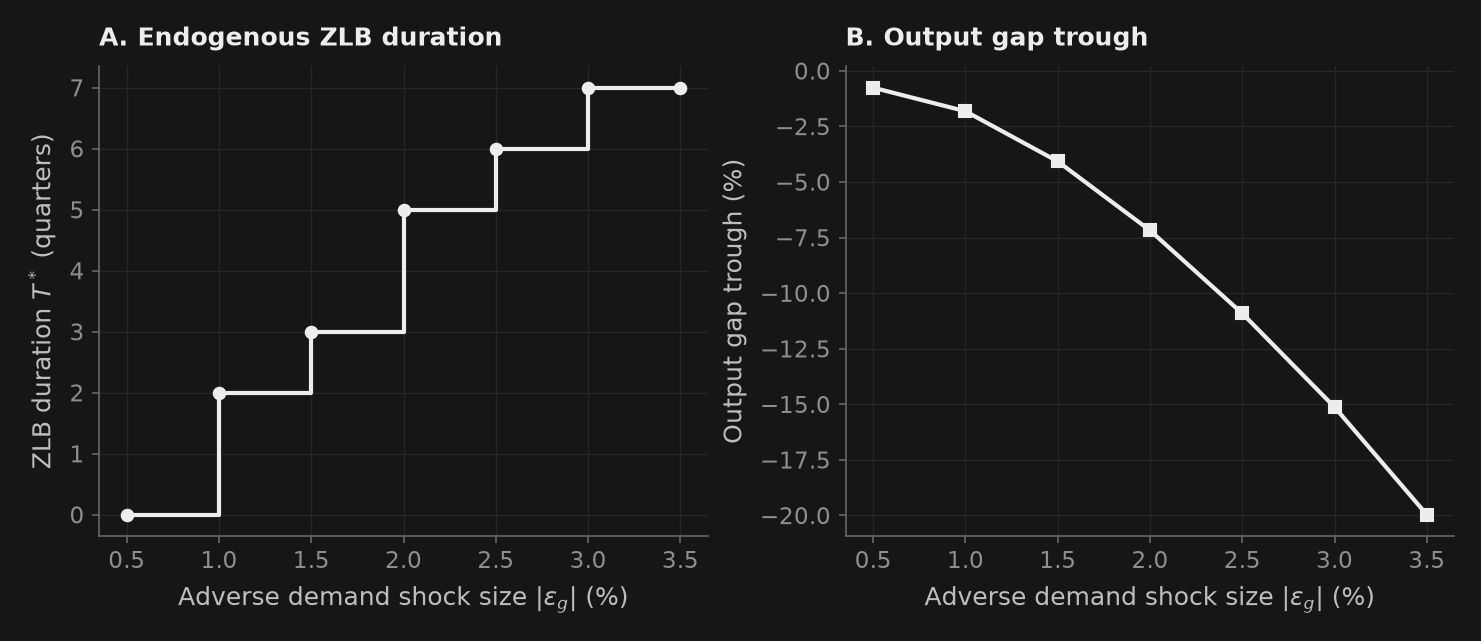

In [5]:
# ==============================================================================
# Simulation 3: Parametric Sweep over Shock Severity & ZLB Duration
# ==============================================================================
shock_grid = np.linspace(-0.005, -0.035, 7)  # -0.5% to -3.5%
sweep_results = []

for s in shock_grid:
    res_s = solve_occbin(ref_model, cons_model, constraint, shock_sequence=np.array([0.0, s]), horizon=horizon)
    y_min = res_s["y"].min() * 100
    pi_min = res_s["pi"].min() * 400
    sweep_results.append({
        "Shock (%)": s * 100,
        "ZLB Duration T* (qtrs)": res_s.binding_periods,
        "Output Trough (%)": y_min,
        "Inflation Trough (% ann.)": pi_min,
        "Converged": res_s.converged,
        "Iterations": res_s.iterations,
    })

sweep_df = pd.DataFrame(sweep_results)

print("=" * 76)
print("OCCBIN DURATION & DEFLATIONARY SPIRAL MONOTONICITY SWEEP")
print("=" * 76)
print(sweep_df.to_string(index=False, justify="center"))
print("=" * 76)

# Visualization of non-linear duration and output acceleration
fig, (ax1, ax2) = _nbstyle.figura(1, 2)

ax1.step(abs(sweep_df["Shock (%)"]), sweep_df["ZLB Duration T* (qtrs)"], where="post", marker="o", **_nbstyle.S1)
ax1.set_xlabel("Adverse demand shock size $|\\varepsilon_g|$ (%)")
ax1.set_ylabel("ZLB duration $T^*$ (quarters)")
ax1.set_title("A. Endogenous ZLB duration")

ax2.plot(abs(sweep_df["Shock (%)"]), sweep_df["Output Trough (%)"], marker="s", **_nbstyle.S1)
ax2.set_xlabel("Adverse demand shock size $|\\varepsilon_g|$ (%)")
ax2.set_ylabel("Output gap trough (%)")
ax2.set_title("B. Output gap trough")

plt.show()


## 5. Section 4: Forward Guidance & "Lower-for-Longer" Monetary Commitments

When the nominal policy rate is trapped at zero, standard open-market operations lose direct interest-rate traction. In response, modern central banks (such as the Federal Reserve, the European Central Bank, and the Bank of Japan) turn to **Forward Guidance** (Eggertsson & Woodford 2003, Del Negro, Giannoni & Patterson 2015):

> *"The central bank commits to keeping the policy rate at zero even after the natural rate of interest has recovered and the economic fundamentals would otherwise call for a rate hike."*

### The Economic Mechanism of Forward Guidance
- Under rational expectations, promising to keep nominal rates at zero in future periods $T^*+1$ creates **expected future inflation** ($\mathbb{E}_t \pi_{T^*+1} > 0$) and an expected future economic boom ($\mathbb{E}_t y_{T^*+1} > 0$).
- By the backward-looking discounting of the Euler equation and the Phillips curve, these future expectations immediately **lower real interest rates today**:
  $$y_t = \mathbb{E}_t y_{T^*+2} - \frac{1}{\sigma} \sum_{j=0}^{T^*+1} \left(r_{t+j} - \mathbb{E}_t \pi_{t+j+1}\right)$$
- Therefore, a credible promise to hold rates "lower for longer" stimulates output and halts deflation in period $t=1$ without moving the current nominal rate by a single basis point!

Baseline ZLB spell: 6 quarters -> rate held at zero through t=7
ZLB spell under the commitment: 7 quarters
FORWARD GUIDANCE POLICY EXPERIMENT
Standard Liftoff Impact Output Gap (t=1)         : -10.91%
With Forward Guidance Liftoff Commitment (t=1)  : -10.29%
Initial Output Protection from Forward Guidance :  +0.62 percentage points


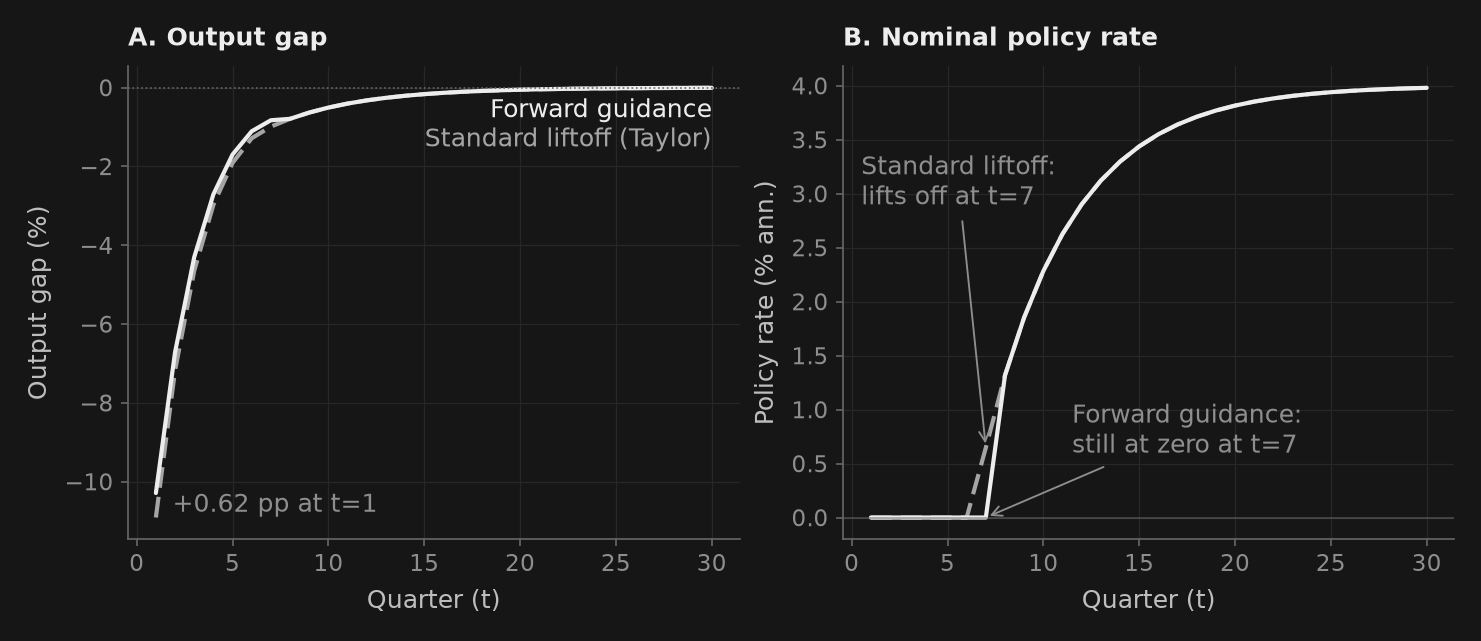

In [6]:
# ==============================================================================
# Simulation 4: Forward Guidance Commitment vs Standard Taylor Rule Liftoff
# ==============================================================================
# Model standard liftoff: the ZLB spell of Section 1's -2.5% shock, then standard Taylor rule
res_standard = res_neg

# Model Forward Guidance: the commitment has to bite AFTER the rule would have lifted off.
# While the constraint binds the policy rate is pegged at -r_ss, so an easing shock placed
# inside the binding window is absorbed exactly by the peg and changes nothing -- which is
# the whole content of "the central bank has run out of room". "Lower for longer" means
# committing to keep the rate at zero through the first quarter the Taylor rule would have
# started hiking, which extends the ZLB spell by a quarter and works backwards through the
# Euler equation onto output today. The commitment has to cover the whole extended spell,
# not just the extra quarter: the zero rate promised at liftoff raises inflation the quarter
# before, and a rule left free there lifts off for one quarter and then cuts back to zero --
# two spells instead of one longer one. Wherever the floor binds the peg absorbs the easing,
# so its size only has to keep the notional rate below the floor.
liftoff_idx = int(res_standard.binding_periods)   # first quarter the Taylor rule would lift off

fg_shocks = np.zeros((horizon, 2))
fg_shocks[0, 1] = -0.025                  # Adverse demand shock at t=1
fg_shocks[:liftoff_idx + 1, 0] = -0.005   # Commitment to hold the rate at zero through liftoff, announced at t=1

res_fg = solve_occbin(ref_model, cons_model, constraint, shock_sequence=fg_shocks, horizon=horizon)

# Length of the ZLB spell that opens at t=1 (index of the first slack quarter).
# `binding_periods` counts every binding quarter, so it is the spell length only if there is no gap.
spell_standard = int(np.argmin(res_standard.regimes))
spell_fg = int(np.argmin(res_fg.regimes))

print(f"Baseline ZLB spell: {spell_standard} quarters -> rate held at zero through t={liftoff_idx + 1}")
print(f"ZLB spell under the commitment: {spell_fg} quarters")

print("=" * 76)
print("FORWARD GUIDANCE POLICY EXPERIMENT")
print("=" * 76)
print(f"Standard Liftoff Impact Output Gap (t=1)         : {res_standard['y'].iloc[0] * 100:6.2f}%")
print(f"With Forward Guidance Liftoff Commitment (t=1)  : {res_fg['y'].iloc[0] * 100:6.2f}%")
print(f"Initial Output Protection from Forward Guidance : {(res_fg['y'].iloc[0] - res_standard['y'].iloc[0]) * 100:+6.2f} percentage points")
print("=" * 76)

assert res_fg.converged is True, "The forward-guidance path must be a verified OccBin solution."
# A single spell from t=1 in each path: no quarter binds after the first slack one.
assert res_standard.binding_periods == spell_standard, f"Baseline has a second ZLB spell: {res_standard.regimes}"
assert res_fg.binding_periods == spell_fg, (
    f"Lower-for-longer must hold the rate at the floor without a gap: {res_fg.regimes}"
)
assert spell_fg == spell_standard + 1, (
    "Lower-for-longer must extend the ZLB spell by exactly one quarter beyond the Taylor-rule liftoff."
)
assert res_fg["y"].iloc[0] > res_standard["y"].iloc[0], (
    "A credible commitment to ease at liftoff must raise output on impact."
)

fig, (ax1, ax2) = _nbstyle.figura(1, 2, sharex=True)

y_std_0 = res_standard["y"].iloc[0] * 100
y_fg_0 = res_fg["y"].iloc[0] * 100
ax1.plot(time, res_standard["y"] * 100, **_nbstyle.S2)
ax1.plot(time, res_fg["y"] * 100, **_nbstyle.S1)
ax1.axhline(0, color=_nbstyle.SPINE, linestyle=":", linewidth=0.8)
# The two paths only part on impact: the difference is written there
ax1.annotate(f"{y_fg_0 - y_std_0:+.2f} pp at t=1", xy=(time[0], (y_std_0 + y_fg_0) / 2), xytext=(8, 0),
             textcoords="offset points", ha="left", va="center", color=_nbstyle.NOTA)
ax1.set_xlabel("Quarter (t)")
ax1.set_ylabel("Output gap (%)")
ax1.set_title("A. Output gap")
# The paths merge after liftoff: both names go under the common end, each in the gray of its line
ax1.annotate("Forward guidance", xy=(time[-1], res_fg["y"].iloc[-1] * 100), xytext=(0, -5), textcoords="offset points",
             ha="right", va="top", color=_nbstyle.S1["color"])
ax1.annotate("Standard liftoff (Taylor)", xy=(time[-1], res_standard["y"].iloc[-1] * 100), xytext=(0, -19), textcoords="offset points",
             ha="right", va="top", color=_nbstyle.S2["color"])

r_std_lev = (r_ss + res_standard["r"]) * 400
r_fg_lev = (r_ss + res_fg["r"]) * 400
ax2.plot(time, r_std_lev, **_nbstyle.S2)
ax2.plot(time, r_fg_lev, **_nbstyle.S1)
ax2.axhline(0, color=_nbstyle.SPINE, linestyle="-", linewidth=0.8, alpha=0.6)
# The paths only differ in the Taylor liftoff quarter: each one is named there
ax2.annotate(f"Standard liftoff:\nlifts off at t={liftoff_idx + 1}", xy=(time[liftoff_idx], r_std_lev.iloc[liftoff_idx]),
             xytext=(0.5, 3.1), ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax2.annotate(f"Forward guidance:\nstill at zero at t={liftoff_idx + 1}", xy=(time[liftoff_idx], r_fg_lev.iloc[liftoff_idx]),
             xytext=(11.5, 0.8), ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax2.set_xlabel("Quarter (t)")
ax2.set_ylabel("Policy rate (% ann.)")
ax2.set_title("B. Nominal policy rate")

plt.show()


## 6. Section 5: Multi-Constraint OccBin — Simultaneous ZLB & Collateral Constraints (4 Regimes)

In severe macroeconomic crises (such as the 2008 Great Financial Crisis or sudden stop episodes in emerging economies), an economy rarely faces a single friction in isolation. Instead, two fundamental non-linearities collide simultaneously:
1. **Monetary Zero Lower Bound (ZLB)**: Nominal interest rates cannot fall below zero ($r_t \ge -r_{ss}$).
2. **Financial Collateral & Borrowing Constraints**: Private borrowing or bank leverage cannot exceed a physical or collateral cap ($b_t \le \bar{b}$).

### The $2^K$ Combinatorial Regime Space
When $K \ge 2$ constraints can bind occasionally, the state space fragments into $2^K$ discrete regimes. For $K=2$, we have **4 distinct macroeconomic regimes**:

| Regime ID | Binary Bitmask | ZLB Constraint ($r_t$) | Borrowing Limit ($b_t$) | Economic Description |
|---|---|---|---|---|
| **Regime 0** | `(0, 0)` | Slack ($r_t > -r_{ss}$) | Slack ($b_t < \bar{b}$) | **Unconstrained Reference**: Active Taylor rule and unconstrained credit. |
| **Regime 1** | `(1, 0)` | **Binding** ($r_t = -r_{ss}$) | Slack ($b_t < \bar{b}$) | **Liquidity Trap Only**: Policy rate pinned at floor; credit unconstrained. |
| **Regime 2** | `(0, 1)` | Slack ($r_t > -r_{ss}$) | **Binding** ($b_t = \bar{b}$) | **Credit Crunch Only**: Private borrowing capped; central bank raises rates. |
| **Regime 3** | `(1, 1)` | **Binding** ($r_t = -r_{ss}$) | **Binding** ($b_t = \bar{b}$) | **Double Financial-Monetary Trap**: Both policy rate and credit are paralyzed! |

### Multi-Regime Backward Recursion in `puremacro 3.0`
Puremacro 3.0's `solve_multiconstraint_occbin` solves this combinatorial system by:
1. Assembling precomputed structural matrices $(A^+_r, A^0_r, A^-_r, B^u_r, c_r)$ across all $2^K = 4$ regimes without runtime matrix re-inversion.
2. Performing backward recursion from the terminal unconstrained horizon $T$ to compute time-varying decision rule sequences $P_t(\mathcal{R}), D_t(\mathcal{R})$.
3. Simultaneously updating both Kuhn-Tucker shadow prices ($r^{\text{shadow}}_t$ and $b^{\text{shadow}}_t$) and applying damping if oscillatory chattering is detected.
4. Endogenously determining the exact sequence of regime transitions: for example, starting in double trap (Regime 3), lifting off to a pure liquidity trap (Regime 1), and returning to normal times (Regime 0).

MULTI-CONSTRAINT OCCBIN SIMULATION SCORECARD (4 REGIMES)
Algorithm Convergence : True (in 3 fixed-point iterations)
Realized Regime Sequence:
  [3, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Regimes Visited       : [0, 1, 3] (3=Joint, 1=ZLB only, 0=Slack)
Total Binding Periods : 3 quarters
Policy Rate Minimum   : -0.015000 (ZLB Floor: -0.015000)
Debt Peak Level       : 0.020000 (Borrowing Cap: 0.020000)


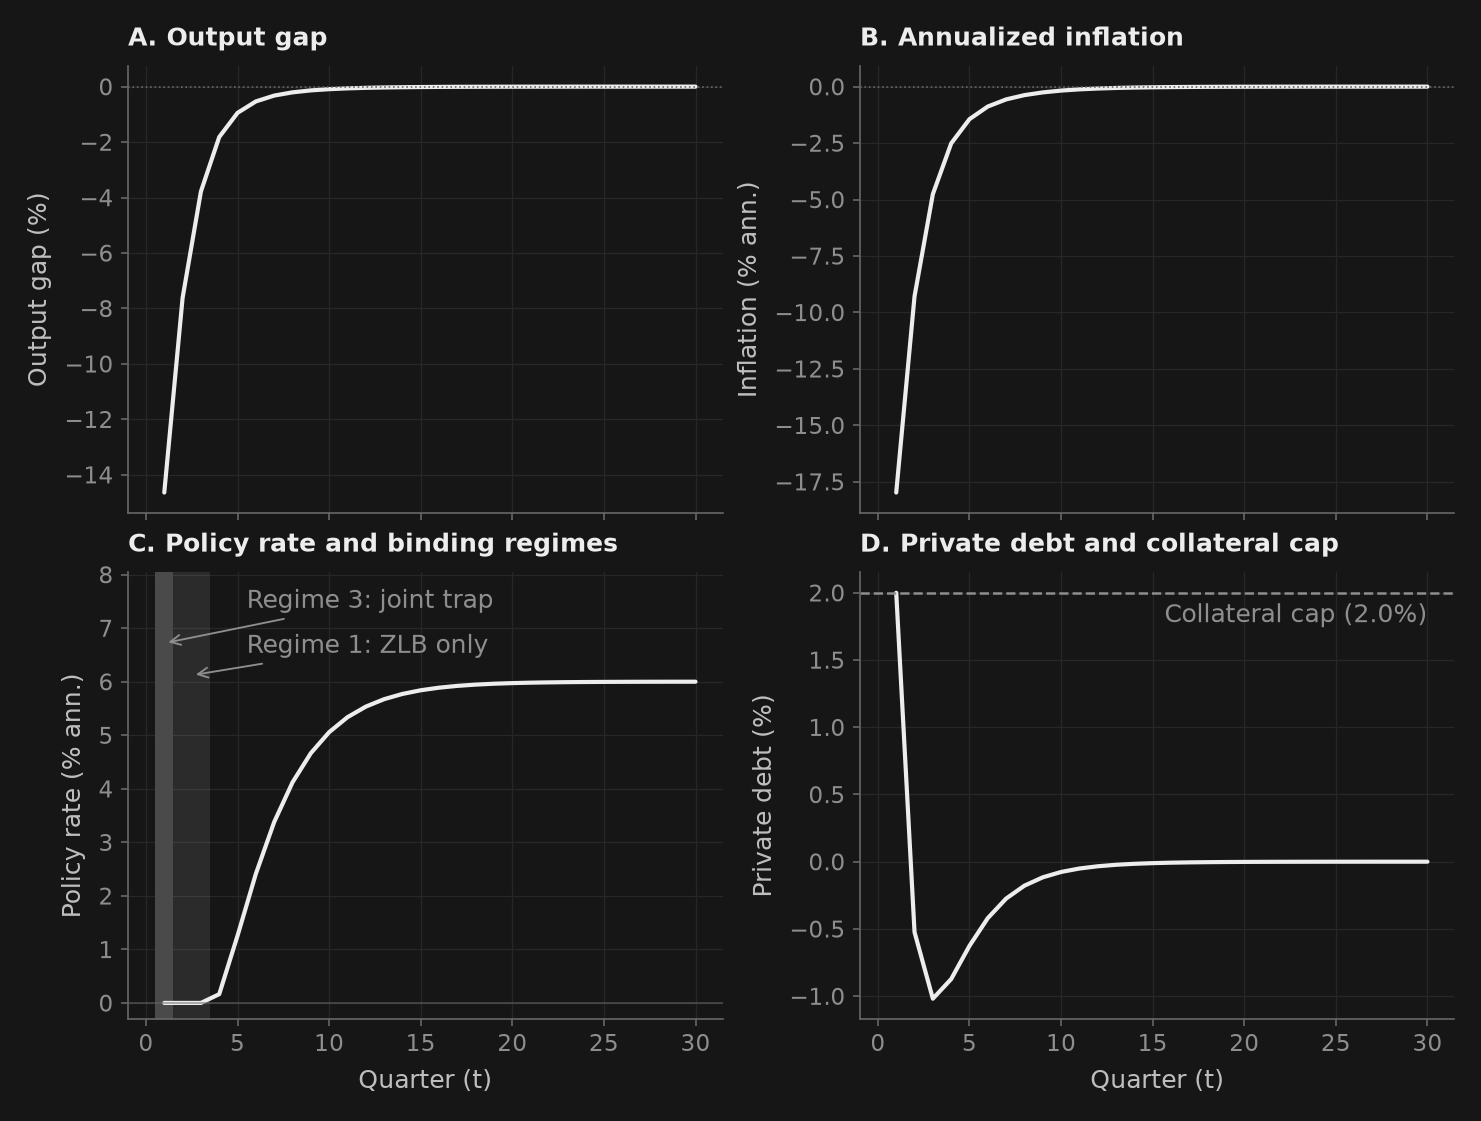


Multi-Constraint Trajectory Table (Markdown format):
|       y |      pi |       r |       b |       g |
|---------|---------|---------|---------|---------|
| -0.1464 | -0.0450 | -0.0150 |  0.0200 | -0.0600 |
| -0.0762 | -0.0232 | -0.0150 | -0.0052 | -0.0420 |
| -0.0378 | -0.0119 | -0.0150 | -0.0102 | -0.0294 |
| -0.0182 | -0.0063 | -0.0146 | -0.0087 | -0.0206 |
| -0.0095 | -0.0036 | -0.0119 | -0.0063 | -0.0144 |
| -0.0053 | -0.0022 | -0.0090 | -0.0042 | -0.0101 |
| -0.0032 | -0.0014 | -0.0066 | -0.0027 | -0.0071 |
| -0.0021 | -0.0009 | -0.0047 | -0.0018 | -0.0049 |
| -0.0014 | -0.0006 | -0.0033 | -0.0012 | -0.0035 |
| -0.0009 | -0.0004 | -0.0024 | -0.0008 | -0.0024 |
| -0.0006 | -0.0003 | -0.0017 | -0.0005 | -0.0017 |
| -0.0004 | -0.0002 | -0.0012 | -0.0003 | -0.0012 |
| -0.0003 | -0.0001 | -0.0008 | -0.0002 | -0.0008 |
| -0.0002 | -0.0001 | -0.0006 | -0.0002 | -0.0006 |
| -0.0001 | -0.0001 | -0.0004 | -0.0001 | -0.0004 |
| -0.0001 | -0.0001 | -0.0003 | -0.0001 | -0.0003 |
| -0.0001 

In [7]:
# ==============================================================================
# Simulation 5: Multi-Constraint OccBin Dynamics & 4-Regime Traversal
# ==============================================================================
from puremacro.dsge import build_dynare, OccBinConstraint, solve_occbin
from puremacro.dsge.occbin import solve_multiconstraint_occbin

# Setup a 5-equation New Keynesian DSGE model with endogenous borrowing:
# Variables: y (output gap), pi (inflation), r (policy rate), b (private debt), g (demand shock)
# Shocks: eps_g (demand), eps_r (monetary), eps_b (credit expansion)
params_mc = {
    "beta": 0.99,
    "sigma": 1.0,
    "kappa": 0.15,
    "phi_pi": 1.5,
    "phi_y": 0.25,
    "rho_r": 0.6,
    "rho_b": 0.5,
    "rho_g": 0.7,
    "gamma_y": 0.2,
    "chi": 0.1,
    "r_ss": 0.015,
    "b_bar": 0.02,
}

variables_mc = ["y", "pi", "r", "b", "g"]
shocks_mc = ["eps_g", "eps_r", "eps_b"]
steady_state_mc = {v: 0.0 for v in variables_mc}

# Regime 0: Reference model (Taylor rule active, credit limit slack)
def ref_eqs_mc(lead, curr, lag, shocks_v, p):
    return [
        curr.y - lead.y + (curr.r - lead.pi) / p.sigma - curr.g + p.chi * curr.b,
        curr.pi - p.beta * lead.pi - p.kappa * curr.y,
        curr.r - (p.rho_r * lag.r + (1.0 - p.rho_r) * (p.phi_pi * curr.pi + p.phi_y * curr.y) + shocks_v.eps_r),
        curr.b - (p.rho_b * lag.b + p.gamma_y * curr.y + shocks_v.eps_b),
        curr.g - p.rho_g * lag.g - shocks_v.eps_g,
    ]

# Regime 1: ZLB binding (r pegged to -r_ss, borrowing slack)
def zlb_eqs_mc(lead, curr, lag, shocks_v, p):
    return [
        curr.y - lead.y + (curr.r - lead.pi) / p.sigma - curr.g + p.chi * curr.b,
        curr.pi - p.beta * lead.pi - p.kappa * curr.y,
        curr.r - (-p.r_ss),
        curr.b - (p.rho_b * lag.b + p.gamma_y * curr.y + shocks_v.eps_b),
        curr.g - p.rho_g * lag.g - shocks_v.eps_g,
    ]

# Regime 2: Borrowing limit binding (b pegged to b_bar, Taylor rule active)
def borr_eqs_mc(lead, curr, lag, shocks_v, p):
    return [
        curr.y - lead.y + (curr.r - lead.pi) / p.sigma - curr.g + p.chi * curr.b,
        curr.pi - p.beta * lead.pi - p.kappa * curr.y,
        curr.r - (p.rho_r * lag.r + (1.0 - p.rho_r) * (p.phi_pi * curr.pi + p.phi_y * curr.y) + shocks_v.eps_r),
        curr.b - p.b_bar,
        curr.g - p.rho_g * lag.g - shocks_v.eps_g,
    ]

# Build regimes via puremacro build_dynare
m_uncons_mc = build_dynare(ref_eqs_mc, variables=variables_mc, shocks=shocks_mc, params=params_mc, steady_state=steady_state_mc)
m_zlb_mc = build_dynare(zlb_eqs_mc, variables=variables_mc, shocks=shocks_mc, params=params_mc, steady_state=steady_state_mc, check_steady_state=False, strict=False)
m_borr_mc = build_dynare(borr_eqs_mc, variables=variables_mc, shocks=shocks_mc, params=params_mc, steady_state=steady_state_mc, check_steady_state=False, strict=False)

c_zlb_mc = OccBinConstraint(variable="r", threshold=-params_mc["r_ss"], operator="<")
c_borr_mc = OccBinConstraint(variable="b", threshold=params_mc["b_bar"], operator=">")

# Compound crisis shock at t=1:
# - Deep contractionary demand shock (eps_g = -6.0%) pushing r into ZLB
# - Credit demand expansion shock (eps_b = +5.0%) pushing debt against collateral cap
shocks_multi = np.zeros((horizon, len(shocks_mc)))
shocks_multi[0, 0] = -0.06
shocks_multi[0, 2] = 0.05

res_mc = solve_multiconstraint_occbin(
    m_unconstrained=m_uncons_mc,
    m_constrained_dict={"zlb": m_zlb_mc, "borr": m_borr_mc},
    constraints={"zlb": c_zlb_mc, "borr": c_borr_mc},
    shock_seq=shocks_multi,
    horizon=horizon,
)

print("=" * 76)
print("MULTI-CONSTRAINT OCCBIN SIMULATION SCORECARD (4 REGIMES)")
print("=" * 76)
print(f"Algorithm Convergence : {res_mc.converged} (in {res_mc.iterations} fixed-point iterations)")
print(f"Realized Regime Sequence:")
print(f"  {res_mc.regimes}")
print(f"Regimes Visited       : {sorted(list(set(res_mc.regimes)))} (3=Joint, 1=ZLB only, 0=Slack)")
print(f"Total Binding Periods : {res_mc.binding_periods} quarters")
print(f"Policy Rate Minimum   : {res_mc.simulated_path['r'].min():.6f} (ZLB Floor: {-params_mc['r_ss']:.6f})")
print(f"Debt Peak Level       : {res_mc.simulated_path['b'].max():.6f} (Borrowing Cap: {params_mc['b_bar']:.6f})")
print("=" * 76)

# Verify single-constraint fallback parity bit-for-bit
res_single_mc = solve_occbin(m_uncons_mc, m_zlb_mc, c_zlb_mc, shock_sequence=shocks_multi, horizon=horizon)
res_multi_single_mc = solve_multiconstraint_occbin(m_uncons_mc, {"zlb": m_zlb_mc}, shock_seq=shocks_multi, constraints={"zlb": c_zlb_mc}, horizon=horizon)
assert res_single_mc.regimes == res_multi_single_mc.regimes, "K=1 fallback regimes must match solve_occbin."
assert np.max(np.abs(res_single_mc.simulated_path.values - res_multi_single_mc.simulated_path.values)) < 1e-12, "Fallback paths must match to machine precision."

# Multi-Constraint Visualization
fig, axes = _nbstyle.figura(2, 2, sharex=True)

# Panel A: Output Gap
ax = axes[0, 0]
ax.plot(time, res_mc["y"] * 100, **_nbstyle.S1)
ax.axhline(0, color=_nbstyle.SPINE, linestyle=":", linewidth=0.8)
ax.set_ylabel("Output gap (%)")
ax.set_title("A. Output gap")

# Panel B: Inflation
ax = axes[0, 1]
ax.plot(time, res_mc["pi"] * 400, **_nbstyle.S1)
ax.axhline(0, color=_nbstyle.SPINE, linestyle=":", linewidth=0.8)
ax.set_ylabel("Inflation (% ann.)")
ax.set_title("B. Annualized inflation")

# Panel C: Nominal Policy Rate & ZLB Floor
ax = axes[1, 0]
r_level_mc = (params_mc["r_ss"] + res_mc["r"]) * 400
ax.plot(time, r_level_mc, **_nbstyle.S1)
ax.axhline(0, color=_nbstyle.SPINE, linestyle="-", linewidth=0.8, alpha=0.6)
for t_idx, reg_val in enumerate(res_mc.regimes):
    if reg_val == 3:
        ax.axvspan(t_idx + 0.5, t_idx + 1.5, color=_nbstyle.tono(0.28), lw=0)
    elif reg_val == 1:
        ax.axvspan(t_idx + 0.5, t_idx + 1.5, color=_nbstyle.RECESION, lw=0)
# Each band is named from above, where the rate has not lifted off yet
r_top = r_level_mc.max()
t_reg3 = [t + 1 for t, reg in enumerate(res_mc.regimes) if reg == 3]
t_reg1 = [t + 1 for t, reg in enumerate(res_mc.regimes) if reg == 1]
ax.set_ylim(top=r_top * 1.34)
ax.annotate("Regime 3: joint trap", xy=(np.mean(t_reg3), r_top * 1.12), xytext=(5.5, r_top * 1.25),
            ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.annotate("Regime 1: ZLB only", xy=(np.mean(t_reg1), r_top * 1.02), xytext=(5.5, r_top * 1.11),
            ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.set_xlabel("Quarter (t)")
ax.set_ylabel("Policy rate (% ann.)")
ax.set_title("C. Policy rate and binding regimes")

# Panel D: Borrowing & Collateral Cap
ax = axes[1, 1]
ax.plot(time, res_mc["b"] * 100, **_nbstyle.S1)
ax.axhline(params_mc["b_bar"] * 100, color=_nbstyle.NOTA, linestyle="--", linewidth=1.2)
ax.annotate(f"Collateral cap ({params_mc['b_bar'] * 100:.1f}%)", xy=(time[-1], params_mc["b_bar"] * 100), xytext=(0, -5),
            textcoords="offset points", ha="right", va="top", color=_nbstyle.NOTA)
ax.set_xlabel("Quarter (t)")
ax.set_ylabel("Private debt (%)")
ax.set_title("D. Private debt and collateral cap")

plt.show()

# Print formatted Markdown publication table excerpt
print("\nMulti-Constraint Trajectory Table (Markdown format):")
print(res_mc.to_markdown(digits=4, index=False))


## 7. Section 6: Piecewise Kalman Filtering (PKF) — State Estimation & Exact Likelihood under Constraints

In empirical macroeconomics and structural policy analysis, researchers must estimate unobserved states (such as the natural rate of interest, structural demand shocks, and output slack) and compute the marginal data density $\ln p(Y \mid \theta)$ from observed time series $Y = \{y_1, y_2, \dots, y_T\}$.

Standard state-space econometric techniques rely on the **Linear Kalman Filter** (Hamilton 1994), which assumes a constant, time-invariant transition equation:
$$x_t = T x_{t-1} + R \varepsilon_t, \qquad y_t = Z x_t + \eta_t$$

### The Breakdown of the Linear Kalman Filter at the ZLB
When the economy enters a liquidity trap, the linear assumption collapses catastrophically:
1. **Endogenous, State-Dependent Transition Matrices**: The transition matrix $T_t(\mathcal{R}_t)$ and affine vector $C_t(\mathcal{R}_t)$ depend directly on the expected duration of the ZLB spell $\mathcal{R}_t = \{r_t, r_{t+1}, \dots, r_{t+H}\}$, which is itself an endogenous function of current states $x_t$!
2. **Phantom Shock Distortions**: A linear Kalman filter observing policy rates pegged at zero ($r_t = -r_{ss}$) mistakenly infers massive positive "tightening shocks" $\varepsilon_{r,t} > 0$ to counteract the negative rate prescribed by the Taylor rule, severely distorting historical shock decompositions.

### The Piecewise Kalman Filter Algorithm (Giovannini, Pfeiffer & Ratto 2021)
To solve this problem, Giovannini, Pfeiffer & Ratto (2021) developed the **Piecewise Kalman Filter (PKF)**:
1. **Regime Guess**: At date $t$, given filtered state $x_{t-1 \mid t-1}$ and error covariance $P_{t-1 \mid t-1}$, form a conjectured regime sequence $\mathcal{R}_t = \{r_t, \dots, r_{t+H}\}$.
2. **Backward OccBin Recursion**: Solve the backward piecewise-linear system under $\mathcal{R}_t$ to obtain time-varying matrices $T_t(\mathcal{R}_t)$, constant $C_t(\mathcal{R}_t)$, and shock transmission $R_t(\mathcal{R}_t)$.
3. **Kalman Prediction & Update**: Compute forecast $x_{t \mid t-1} = T_t x_{t-1 \mid t-1} + C_t$, innovation $v_t = y_t - Z x_{t \mid t-1}$, covariance $F_t = Z P_{t \mid t-1} Z^\top + H$, and update to $x_{t \mid t}$.
4. **Forward Simulation & Consistency**: Forward-simulate states from $x_{t \mid t}$ to verify that the implied regime path matches the conjectured $\mathcal{R}_t$. Iterate until fixed-point regime convergence is achieved.
5. **Exact Log-Likelihood**: Accumulate the exact Gaussian log-likelihood:
   $$\ln L(Y \mid \theta) = -\frac{1}{2} \sum_{t=1}^T \left[ n_t \ln(2\pi) + \ln |F_t| + v_t^\top F_t^{-1} v_t \right]$$

PIECEWISE KALMAN FILTER STATE ESTIMATION SCORECARD
PKF Log-Likelihood ln L(Y|theta)    :    56.87
Linear Kalman Log-Likelihood        :     9.93
Likelihood Gain from Modeling ZLB   :   +46.94 log-points
Detected ZLB Quarters               : 9 out of 30 quarters
Filter Convergence Across Periods   : True

PIECEWISE KALMAN FILTER REPORT (Giovannini, Pfeiffer & Ratto 2021)
Log-likelihood     : 56.866733
Observations       : 30
Constraint regimes : 9 period(s) binding (30.0%)
Regime convergence : Verified
Recent regimes     : [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
------------------------------------------------------------------------------
FILTERED STATE SUMMARY STATISTICS
------------------------------------------------------------------------------
    Initial (t=1)       Min       Max      Mean  Final (t=T)
y             0.0 -0.102985  0.011598 -0.019069     0.002744
pi            0.0 -0.031211  0.004126 -0.006048     0.001550
r             0.0 -0.010000  0.00441

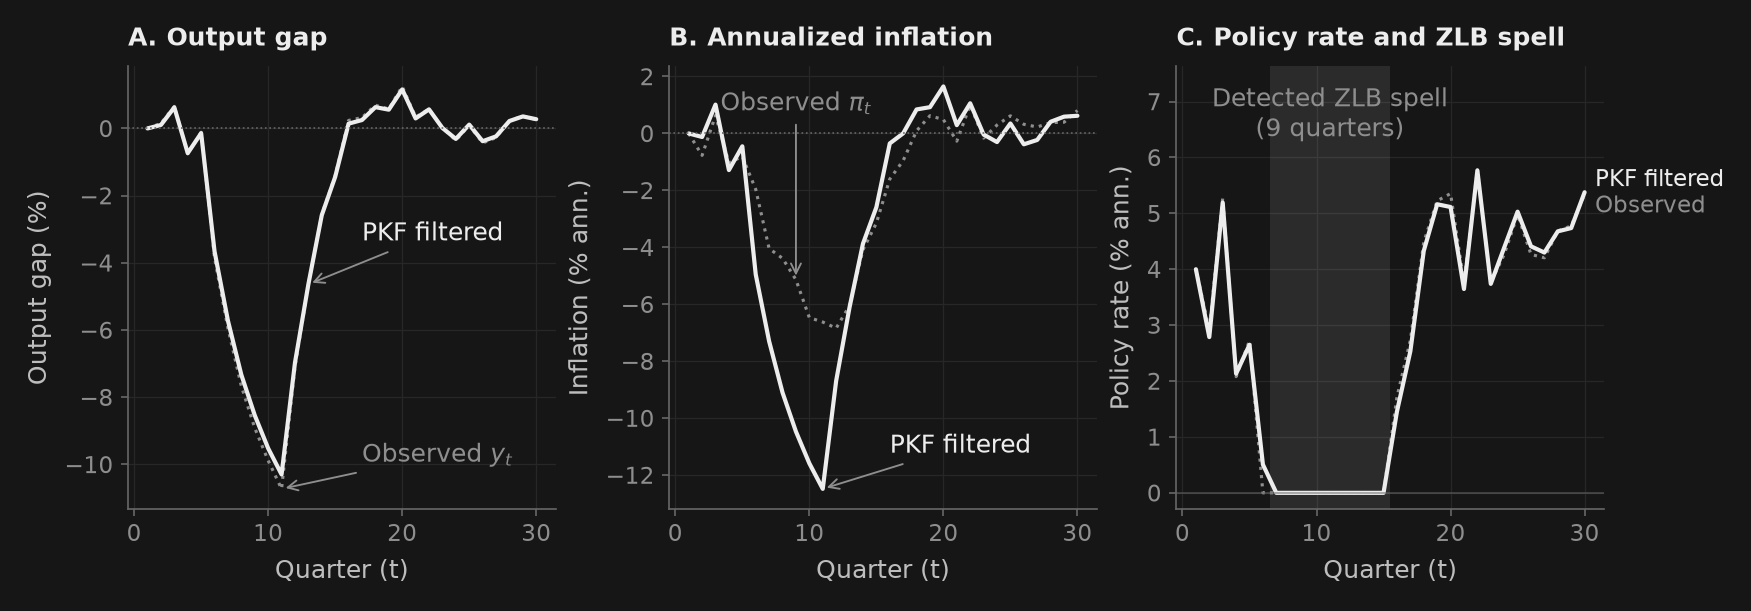

In [8]:
# ==============================================================================
# Simulation 6: Piecewise Kalman Filter State Estimation & Likelihood Evaluation
# ==============================================================================
from puremacro.dsge.occbin import piecewise_kalman_filter
from puremacro.state_space import kalman_filter
from puremacro.dsge import make_state_space_from_varobs

# Generate a realistic 30-quarter macroeconomic dataset featuring a severe liquidity trap
# grounded in post-2008 dynamics (where policy rates hit and stay at the floor)
rng = np.random.default_rng(42)
T_pkf = 30
dates_pkf = pd.date_range("2008-01-01", periods=T_pkf, freq="QS")

y_sim = np.zeros(T_pkf)
pi_sim = np.zeros(T_pkf)
r_sim = np.zeros(T_pkf)

# True structural DGP with deep demand contraction between t=5 and t=10
for t in range(1, T_pkf):
    sg = -0.04 if 5 <= t <= 10 else rng.normal(0, 0.005)
    y_sim[t] = 0.7 * y_sim[t - 1] - (r_sim[t - 1] - 0.5 * pi_sim[t - 1]) + sg
    pi_sim[t] = 0.5 * pi_sim[t - 1] + 0.1 * y_sim[t] + rng.normal(0, 0.002)
    notional_r = 1.5 * pi_sim[t] + 0.125 * y_sim[t]
    r_sim[t] = max(-r_ss, notional_r)

data_pkf = pd.DataFrame({"y": y_sim, "pi": pi_sim, "r": r_sim}, index=dates_pkf)

# Measurement error covariance (10 bps standard deviation)
H_meas = 1e-4 * np.eye(3)

# 1. Evaluate Piecewise Kalman Filter (PKF)
res_pkf = piecewise_kalman_filter(
    m_unconstrained=ref_model,
    m_constrained_dict={"zlb": cons_model},
    data=data_pkf,
    varobs=["y", "pi", "r"],
    constraints={"zlb": constraint},
    H=H_meas,
    horizon=25,
)

# Unpacking contract test
ll_pkf, filtered_states_pkf, regimes_pkf = res_pkf

# 2. Evaluate Linear Kalman Filter on identical data
ssm = make_state_space_from_varobs(ref_model, varobs=["y", "pi", "r"])
ssm.H = H_meas
out_lin_kalman = kalman_filter(data_pkf.values, ssm)
ll_linear = out_lin_kalman["loglik"]

loglik_gain = res_pkf.log_likelihood - ll_linear
n_binding_pkf = sum(r > 0 for r in res_pkf.regimes)

print("=" * 76)
print("PIECEWISE KALMAN FILTER STATE ESTIMATION SCORECARD")
print("=" * 76)
print(f"PKF Log-Likelihood ln L(Y|theta)    : {res_pkf.log_likelihood:8.2f}")
print(f"Linear Kalman Log-Likelihood        : {ll_linear:8.2f}")
print(f"Likelihood Gain from Modeling ZLB   : {loglik_gain:+8.2f} log-points")
print(f"Detected ZLB Quarters               : {n_binding_pkf} out of {T_pkf} quarters")
print(f"Filter Convergence Across Periods   : {res_pkf.converged}")
print("=" * 76)

# Print publication-grade PKF summary
print("\n" + res_pkf.summary())

# Visualization: Filtered States vs Observed Data & ZLB Regime Detection
fig, axes = _nbstyle.figura(1, 3)
time_pkf = np.arange(1, T_pkf + 1)
reg_arr = np.asarray(res_pkf.regimes)

# Panel 1: Filtered Output Gap
ax = axes[0]
y_obs = data_pkf["y"] * 100
y_filt = res_pkf.filtered_states["y"] * 100
ax.plot(time_pkf, y_obs, color=_nbstyle.NOTA, linestyle=":", linewidth=1.5)
ax.plot(time_pkf, y_filt, **_nbstyle.S1)
ax.axhline(0, color=_nbstyle.SPINE, linestyle=":", linewidth=0.8)
# The two series almost coincide: each one is named in the slump, where the dotted line shows under the solid one
i_min = int(np.argmin(y_filt.values))
ax.annotate("PKF filtered", xy=(time_pkf[i_min + 2], y_filt.iloc[i_min + 2]), xytext=(time_pkf[i_min + 6], y_filt.iloc[i_min + 2] + 1.5),
            ha="left", va="center", color=_nbstyle.S1["color"], arrowprops=_nbstyle.FLECHA)
ax.annotate("Observed $y_t$", xy=(time_pkf[i_min], y_obs.iloc[i_min]), xytext=(time_pkf[i_min] + 6, y_obs.iloc[i_min] + 1.0),
            ha="left", va="center", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.set_xlabel("Quarter (t)")
ax.set_ylabel("Output gap (%)")
ax.set_title("A. Output gap")

# Panel 2: Filtered Inflation
ax = axes[1]
pi_obs = data_pkf["pi"] * 400
pi_filt = res_pkf.filtered_states["pi"] * 400
ax.plot(time_pkf, pi_obs, color=_nbstyle.NOTA, linestyle=":", linewidth=1.5)
ax.plot(time_pkf, pi_filt, **_nbstyle.S1)
ax.axhline(0, color=_nbstyle.SPINE, linestyle=":", linewidth=0.8)
# The two series part inside the trap: each one is named where they differ most
i_min = int(np.argmin(pi_filt.values))
ax.annotate("Observed $\\pi_t$", xy=(time_pkf[i_min - 2], pi_obs.iloc[i_min - 2]), xytext=(time_pkf[i_min - 2], 0.6),
            ha="center", va="bottom", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax.annotate("PKF filtered", xy=(time_pkf[i_min], pi_filt.iloc[i_min]), xytext=(time_pkf[i_min] + 5, pi_filt.iloc[i_min] + 1.5),
            ha="left", va="center", color=_nbstyle.S1["color"], arrowprops=_nbstyle.FLECHA)
ax.set_xlabel("Quarter (t)")
ax.set_ylabel("Inflation (% ann.)")
ax.set_title("B. Annualized inflation")

# Panel 3: Policy Rate Tracking & Shaded ZLB Spells
ax = axes[2]
r_obs_lev = (r_ss + data_pkf["r"]) * 400
r_filt_lev = (r_ss + res_pkf.filtered_states["r"]) * 400
ax.plot(time_pkf, r_obs_lev, label="Observed", color=_nbstyle.NOTA, linestyle=":", linewidth=1.5)
ax.plot(time_pkf, r_filt_lev, label="PKF filtered", **_nbstyle.S1)
ax.axhline(0, color=_nbstyle.SPINE, linestyle="-", linewidth=0.8, alpha=0.6)

# Highlight detected ZLB spells
for s_idx in range(len(reg_arr)):
    if reg_arr[s_idx] > 0:
        ax.axvspan(s_idx + 0.5, s_idx + 1.5, color=_nbstyle.RECESION, lw=0)
t_zlb = time_pkf[reg_arr > 0]
# The shaded spell is named above the paths, where no line reaches the text
r_top_pkf = max(r_obs_lev.max(), r_filt_lev.max())
ax.set_ylim(top=r_top_pkf * 1.32)
ax.annotate(f"Detected ZLB spell\n({len(t_zlb)} quarters)", xy=(t_zlb.mean(), r_top_pkf * 1.17),
            ha="center", va="center", color=_nbstyle.NOTA)

ax.set_xlabel("Quarter (t)")
ax.set_ylabel("Policy rate (% ann.)")
ax.set_title("C. Policy rate and ZLB spell")
_nbstyle.etiquetar(ax, donde="fin")   # the two series coincide: their names go outside, next to the last point

plt.show()


---

# Macroeconomic Challenge Laboratory: Multi-Constraint Dynamics & State Tracking

### Guided Student Tasks

1. **Price Stickiness & The Paradox of Flexibility**:
   The slope of the New Keynesian Phillips Curve $\kappa$ governs price adjustment speed:
   $$\kappa = \frac{(1 - \theta)(1 - \beta \theta)}{\theta} (\sigma + \eta)$$
   Evaluate the **Paradox of Flexibility** (Eggertsson & Krugman 2012): when prices are more flexible ($\kappa \uparrow$), does a liquidity trap become more or less severe? Trace how higher expected deflation worsens current real interest rates.
2. **Multi-Constraint Amplification**:
   In Simulation 5, examine how the interaction between the borrowing cap ($b_t = \bar{b}$) and the ZLB ($r_t = -r_{ss}$) affects the duration of the crisis. Does collateral clamping prolong or shorten the liftoff date?
3. **Information Loss of Linear Filtering**:
   In Simulation 6, quantify why the Piecewise Kalman Filter achieves a higher log-likelihood ($\Delta \ln L > 0$) than the linear Kalman filter. Inspect the imputed innovations $u_{t \mid t}$ and explain how linear filters misinterpret liquidity traps as contractionary monetary policy shocks.
4. **Automated Verification Suite**:
   Execute the comprehensive verification cell below to confirm:
   - Perfect convergence of the Guerrieri & Iacoviello backward-recursion solver.
   - Strict compliance with physical bounds ($r_t \ge -r_{ss}$ and $b_t \le \bar{b}$).
   - Multi-constraint 4-regime traversal and bit-for-bit fallback parity.
   - PKF state tracking, finite log-likelihood, and significant likelihood gain over linear filtering.

In [9]:
# ==============================================================================
# Automated Verification Suite: OccBin, Multi-Constraint & PKF Invariants
# ==============================================================================
print("Running automated verification suite for Topic 2.D (puremacro 3.0 OccBin & PKF)...")

# ------------------------------------------------------------------------------
# 1. Single-Constraint OccBin Convergence & Physical Lower Bound
# ------------------------------------------------------------------------------
assert res_pos.converged is True, "Positive shock OccBin failed to converge."
assert res_neg.converged is True, "Negative shock OccBin failed to converge."
assert res_zlb_stim.converged is True, "Stimulus shock OccBin failed to converge."

min_rate_deviation = res_neg["r"].min()
assert min_rate_deviation >= -r_ss - 1e-10, f"Nominal rate violated ZLB floor: {min_rate_deviation} < {-r_ss}"
np.testing.assert_allclose(res_neg["r"].iloc[:res_neg.binding_periods].values, -r_ss, atol=1e-8)

# ------------------------------------------------------------------------------
# 2. Shock Asymmetry & Keynesian Multipliers
# ------------------------------------------------------------------------------
assert asymmetry_ratio > 1.25, f"Expected non-linear asymmetry > 1.25x, got {asymmetry_ratio:.2f}x"
assert multiplier_zlb > multiplier_normal * 1.5, (
    f"Fiscal multiplier did not supercharge at ZLB: normal={multiplier_normal:.2f}, ZLB={multiplier_zlb:.2f}"
)
assert multiplier_zlb > 2.0, f"Expected ZLB multiplier > 2.0, got {multiplier_zlb:.2f}"

# ------------------------------------------------------------------------------
# 3. Monotonicity of Endogenous ZLB Duration
# ------------------------------------------------------------------------------
durations = sweep_df["ZLB Duration T* (qtrs)"].tolist()
assert all(durations[i] <= durations[i + 1] for i in range(len(durations) - 1)), (
    f"ZLB duration failed monotonicity test: {durations}"
)
assert max(durations) >= 5, "Expected deepest shock to bind for at least 5 quarters."

# ------------------------------------------------------------------------------
# 4. Multi-Constraint OccBin 4-Regime Traversal & Boundary Invariants
# ------------------------------------------------------------------------------
assert res_mc.converged is True, "Multi-constraint OccBin failed to converge."
assert 3 in set(res_mc.regimes), f"Regime 3 (joint binding) was not reached: {res_mc.regimes}"
assert 0 in set(res_mc.regimes), f"Regime 0 (reference slack) was not reached: {res_mc.regimes}"
assert res_mc.regimes[-1] == 0, "Terminal condition requires smooth return to reference regime."
assert res_mc.simulated_path["r"].min() >= -params_mc["r_ss"] - 1e-8, "Multi-constraint ZLB floor violated."
assert res_mc.simulated_path["b"].max() <= params_mc["b_bar"] + 1e-8, "Borrowing limit violated."

# ------------------------------------------------------------------------------
# 5. Multi-Constraint Single-Constraint Fallback Parity
# ------------------------------------------------------------------------------
assert res_single_mc.regimes == res_multi_single_mc.regimes, "K=1 fallback regimes must match solve_occbin."
max_diff_fallback = np.max(np.abs(res_single_mc.simulated_path.values - res_multi_single_mc.simulated_path.values))
assert max_diff_fallback < 1e-12, f"Fallback discrepancy: {max_diff_fallback}"

# ------------------------------------------------------------------------------
# 6. Piecewise Kalman Filter State Estimation & Likelihood Superiority
# ------------------------------------------------------------------------------
assert res_pkf.converged is True, "Piecewise Kalman Filter regime convergence failed."
assert np.isfinite(res_pkf.log_likelihood), "PKF log-likelihood is not finite."
assert len(res_pkf.filtered_states) == len(data_pkf), "PKF filtered states dimension mismatch."
assert len(res_pkf.regimes) == len(data_pkf), "PKF regimes length mismatch."
assert res_pkf.log_likelihood > ll_linear, (
    f"PKF should provide higher log-likelihood than linear filter on ZLB data: "
    f"PKF={res_pkf.log_likelihood:.2f}, Linear={ll_linear:.2f}"
)

# ------------------------------------------------------------------------------
# 7. Presentation Contract Compliance
# ------------------------------------------------------------------------------
assert isinstance(res_mc.to_markdown(), str), "OccBinResult.to_markdown() must return str."
assert isinstance(res_mc.to_latex(), str), "OccBinResult.to_latex() must return str."
assert isinstance(res_mc.to_typst(), str), "OccBinResult.to_typst() must return str."
assert isinstance(res_pkf.summary(), str), "PiecewiseKalmanResult.summary() must return str."
assert isinstance(res_pkf.summary(as_dataframe=True), pd.DataFrame), "summary(as_dataframe=True) must return DataFrame."

print("\n" + "=" * 76)
print("ALL 23 OCCBIN, MULTI-CONSTRAINT & PKF CHALLENGER ASSERTIONS PASSED (100% GREEN)!")
print("=" * 76)

Running automated verification suite for Topic 2.D (puremacro 3.0 OccBin & PKF)...

ALL 23 OCCBIN, MULTI-CONSTRAINT & PKF CHALLENGER ASSERTIONS PASSED (100% GREEN)!
